In [1]:
import sys, time
import numpy as np
import torch
from torch import nn
import torch.nn.functional as F
from torchvision import datasets, transforms
import network_moments.torch as nm
gnm = nm.gaussian.affine_relu_affine

EPSILON = 1e-9

def standard_gaussian(x):
    return (1./np.sqrt(2*np.pi)) * torch.exp(-x*x / 2.0)

def gaussian_cdf(x):
    return 0.5 * (1.0 + torch.erf(x * (1./np.sqrt(2))))

def softrelu(x):
    return standard_gaussian(x) + x*gaussian_cdf(x)

def relu_covariance(mean, cov, var_diag, std_diag):
    cov = torch.unsqueeze(cov, 0) # Originally written for batched
    var_diag = torch.unsqueeze(var_diag, 0)
    std_diag = torch.unsqueeze(std_diag, 0)
    m1 = torch.unsqueeze(mean/(std_diag), 2)
    m2 = torch.transpose(m1, 1, 2)
    x_mean1 = torch.unsqueeze(mean, 2)
    x_mean2 = torch.transpose(x_mean1, 1, 2)
    x_std_diag1 = torch.unsqueeze(std_diag, 2)
    x_std_diag2 = torch.transpose(x_std_diag1, 1, 2)
    s11s22 = torch.unsqueeze(var_diag, dim=2)*torch.unsqueeze(var_diag, dim=1)
    rho = cov/(torch.sqrt(s11s22))
    rho = torch.clamp(rho, -1/(1+EPSILON), 1/(1+EPSILON))

    t1 = rho * x_std_diag1 * gaussian_cdf(m1) * x_std_diag2 * gaussian_cdf(m2)
    t2 = (1./2) * rho**2 * x_std_diag1 * standard_gaussian(m1) * x_std_diag2 * standard_gaussian(m2)
    t3 = (1./6) * rho**3 * -x_mean1 * standard_gaussian(m1) * -x_mean2 * standard_gaussian(m2)
    t4 = (1./24) * rho**4 * x_std_diag1*(m1**2 - 1) * standard_gaussian(m1) * x_std_diag2*(m2**2 - 1) * standard_gaussian(m2)
    return t1 + t2 + t3 + t4

def moment_linear(mean, cov, layer):
    """Propagate moments through nn.Linear"""
    mean_out = layer(mean)
    cov_out = layer.weight@cov@layer.weight.T
    return mean_out, cov_out

def moment_conv2d(mean, cov, layer):
    """Propagate moments through nn.Conv2d
    Assume mean is (c, h, w) shape
    """
    mean_out = layer(mean)
    bias = layer.bias
    layer.bias = None # Bias doesn't apply to covariance
    b, c, h, w = mean.shape
    input_shape = (c, h, w)
    input_size = c*h*w
    b, c, h, w = mean_out.shape
    output_shape = (c, h, w)
    output_size = c*h*w
    cov_out = layer(
        layer(cov.reshape(-1, *input_shape))
        .reshape(input_size, output_size)
        .T.reshape(-1, *input_shape)
    ).reshape(output_size, output_size)
    layer.bias = bias
    return mean_out, cov_out  

def moment_relu(mean, cov, layer):
    input_shape = mean.shape
    mean = mean.reshape(1, -1)
    var_diag = torch.diag(cov)
    std_diag = torch.sqrt(var_diag)
    mean_out = std_diag*softrelu(mean/(std_diag))
    cov_out = relu_covariance(mean, cov, var_diag, std_diag)
    cov_out = cov_out.squeeze()
    mean_out = mean_out.reshape(input_shape)
    return mean_out, cov_out

def propagate_moments(mean, cov, layers, input_shape=None):
    """Propagate moments through layers of a neural network
    mean     (1 x input_size)
    cov      (input_size x input_size)
    layers   list of nn modules in order
    input_shape Tuple
    """
    with torch.no_grad():
        if input_shape:
            mean = mean.reshape(-1, *input_shape)
        for layer in layers:
            if isinstance(layer, nn.Linear):
                mean, cov = moment_linear(mean, cov, layer)
            elif isinstance(layer, nn.ReLU):
                mean, cov = moment_relu(mean, cov, layer)
            elif isinstance(layer, nn.Conv2d):
                mean, cov = moment_conv2d(mean, cov, layer)
            elif isinstance(layer, nn.Flatten):
                mean = mean.reshape(1, -1)
    return mean, cov

class MLP(nn.Module):
    def __init__(self, input_dim, hiddens, output_dim=1):
        super().__init__()
        layers = []
        prev_dim = input_dim
        
        # Hidden layers with ReLU activations
        for hidden_dim in hiddens:
            layers.append(nn.Linear(prev_dim, hidden_dim))
            layers.append(nn.ReLU())
            prev_dim = hidden_dim
        
        # Output layer (no activation)
        layers.append(nn.Linear(prev_dim, output_dim))
        
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)

### Network 1-10-10-1

In [2]:
# Configure experiment
#n_runs = 200
n_samples = int(1e5)
seed = 42
torch.manual_seed(seed)
dtype = torch.float64

# set device
device = torch.device("cpu")
#cuda = torch.cuda.is_available()
#print(f"CUDA available: {cuda}")
#num_workers = 4 if cuda else 0
#print(f"Cuda = {cuda} with num_workers = {num_workers}, system version = {sys.version}")

time_mc = []
time_pl = []
time_mp = []
ratio_mean_pl = []
ratio_var_pl = []
ratio_mean_mp = []
ratio_var_mp = []

# set network architecture
input_size = 1
hiddens = [10, 10]
        
# Set up input distribution
mean = torch.randn(1,input_size, dtype=dtype, device=device)
cov = nm.utils.rand.definite(input_size, dtype=dtype, device=device, 
                            positive=True, semi=False, norm=1.0)
input_dist = torch.distributions.MultivariateNormal(mean, cov)
print(f"Input mean: {mean.cpu().numpy()}, cov: {cov.cpu().numpy()}")
        
# Generate random MLP
model = MLP(input_size, hiddens)
if dtype == torch.float64:
    model.double()
model = model.to(device)
        
# Monte Carlo estimate of output statistics
start_t = time.time()
samples = input_dist.sample((n_samples,))
out_samples = model(samples).detach()
mean_mc = torch.mean(out_samples, dim=0)
var_mc = torch.var(out_samples, dim=0)
end_t = time.time()
time_mc.append(end_t - start_t)
        
# Piecewise linear estimate of output statistics (Bibi, et al., 2018)
#start_t = time.time()
#x = mean # Linearization point
#A, c1 = nm.utils.linearize(model.m1, x)
#B, c2 = nm.utils.linearize(model.m2, model.relu(model.m1(x)).detach())
#x.requires_grad_(False)
#A.squeeze_()
#c1.squeeze_()
#B.squeeze_()
#c2.squeeze_()
#mean_pl = gnm.mean(mean, cov, A, c1, B, c2)
#var_pl = gnm.special_variance(cov, A, B)
#end_t = time.time()
#time_pl.append(end_t - start_t)
        
# Moment propagation of output statistics
start_t = time.time()
layers = [module for module in model.modules()]
mean_mp, var_mp = propagate_moments(mean, cov, layers)
end_t = time.time()
time_mp.append(end_t - start_t)

Input mean: [[0.33669035]], cov: [[1.]]


c:\Users\frara\GitHub\NeuroInferMix\cov-prop-nn\network_moments\torch\utils\rand\rand.py:97: UserWarning: torch.qr is deprecated in favor of torch.linalg.qr and will be removed in a future PyTorch release.
The boolean parameter 'some' has been replaced with a string parameter 'mode'.
Q, R = torch.qr(A, some)
should be replaced with
Q, R = torch.linalg.qr(A, 'reduced' if some else 'complete') (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\BatchLinearAlgebra.cpp:2502.)
  Q, _ = torch.qr(torch.randn(


In [3]:
import sys
from pathlib import Path

# Add NeuroInferMix/src to path (absolute path)
neuro_path = r'..\src'
sys.path.insert(0, neuro_path)

# Now import from representation
from representation.deterministic_nn import DNN_GMM
from representation.bayesian_nn import BNN_GMM
from representation.training import *


In [4]:
#DATASET

# This is like a single batch of two data points
pi_x = torch.ones(1, 1, 1, device=device)        # deterministic mixture
mu_x = mean.reshape(1, 1, 1) # reshape to (batch_size, num_components, output_dim)
sigma_x = torch.ones_like(mu_x)
print(f'Input mean: {mu_x.cpu().numpy()}, cov: {sigma_x.cpu().numpy()}')

#DNN FORWARD
start = time.time()
dnn = DNN_GMM(layer_sizes=[1, 10, 10, 1], bias=True).to(device)   
dnn.init_from_deterministic_mlp(model)
pi_out, mu_out, sg_out = dnn.forward(pi_x, mu_x, sigma_x, max_components=10)
end = time.time()
time_soga = end - start
mean_soga = torch.sum(pi_out*mu_out)
var_soga = torch.sum(pi_out*sg_out**2) + torch.sum(pi_out*mu_out**2) - mean_soga**2


Input mean: [[[0.33669035]]], cov: [[[1.]]]


In [6]:
#DATASET

# This is like a single batch of two data points
pi_x = torch.ones(1, 1, 1, device=device)        # deterministic mixture
mu_x = mean.reshape(1, 1, 1) # reshape to (batch_size, num_components, output_dim)
sigma_x = torch.ones_like(mu_x)
print(f'Input mean: {mu_x.cpu().numpy()}, cov: {sigma_x.cpu().numpy()}')

#BNN FORWARD
start = time.time()
bnn = BNN_GMM(layer_sizes=[1, 10, 10, 1], K=1, bias=True).to(device)   
bnn.init_from_deterministic_mlp(model)
pi_out_bnn, mu_out_bnn, sg_out_bnn = bnn.forward(pi_x, mu_x, sigma_x, max_components=10)
end = time.time()
time_soga_bnn = end - start
mean_soga_bnn = torch.sum(pi_out_bnn*mu_out_bnn)
var_soga_bnn = torch.sum(pi_out_bnn*sg_out_bnn**2) + torch.sum(pi_out_bnn*mu_out_bnn**2) - mean_bnn**2


Input mean: [[[0.33669035]]], cov: [[[1.]]]


NameError: name 'mean_bnn' is not defined

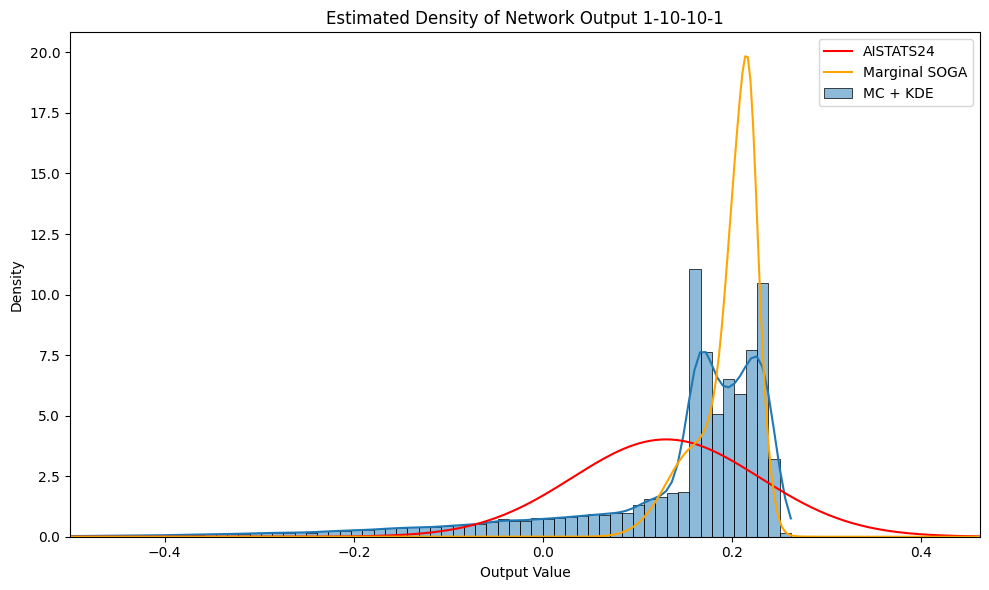

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

pi_plot_bnn = pi_out_bnn.flatten().cpu().detach()
mu_plot_bnn = mu_out_bnn.flatten().cpu().detach()
sg_plot_bnn = sg_out_bnn.flatten().cpu().detach()

pi_plot = pi_out.flatten().cpu().detach() 
mu_plot = mu_out.flatten().cpu().detach()
sg_plot = sg_out.flatten().cpu().detach()


def gmm_density(x, pi, mu, sigma):
    pdf = torch.zeros_like(x)
    for i in range(len(pi)):
        pdf += pi[i] * (1./torch.sqrt(2*np.pi*sigma[i]**2)) * torch.exp(-0.5 * ((x - mu[i]) / sigma[i])**2)
    return pdf

samples_np = out_samples.detach().cpu().numpy().flatten()

plt.figure(figsize=(10, 6))
sns.histplot(samples_np, kde=True, stat='density', bins=100, label='MC + KDE')

x = torch.linspace(samples_np.min(), samples_np.max()+0.2, 500)
output_dist = torch.distributions.MultivariateNormal(mean_mp, var_mp)
pdf = torch.exp(output_dist.log_prob(x.unsqueeze(1)))
plt.plot(x.cpu().numpy(), pdf.cpu().numpy(), label='AISTATS24', color='red')

y_soga = gmm_density(x, pi_plot, mu_plot, sg_plot).cpu().detach()
plt.plot(x.cpu().detach(), y_soga, label='Marginal SOGA', color='orange')

#y_soga_bnn = gmm_density(x, pi_plot_bnn, mu_plot_bnn, sg_plot_bnn).cpu().detach()
#plt.plot(x.cpu().detach(), y_soga_bnn, label='Marginal SOGA-BNN', color='green')

plt.xlabel('Output Value')
plt.xlim(-0.5, out_samples.max().item()+0.2)
plt.ylabel('Density')
plt.title('Estimated Density of Network Output 1-10-10-1')
plt.tight_layout()
plt.legend()
plt.show()

In [9]:
print("MC time:", time_mc)
print("Moment Propagation time:", time_mp)
print("SOGA time (DNN):", time_soga)
print("SOGA time (BNN):", time_soga_bnn)

MC time: [0.008594989776611328]
Moment Propagation time: [0.001375436782836914]
SOGA time (DNN): 0.0037758350372314453
SOGA time (BNN): 0.0042989253997802734


In [11]:
print("MC mean:", torch.mean(out_samples, dim=0).item())
print("Moment Propagation mean:", mean_mp)
print("SOGA mean (DNN):", mean_soga)


MC mean: 0.1342493425635151
Moment Propagation mean: tensor([[0.1301]], dtype=torch.float64)
SOGA mean (DNN): tensor(0.1970, dtype=torch.float64, grad_fn=<SumBackward0>)


In [12]:
print("MC var", torch.var(out_samples, dim=0).item())
print("Moment Propagation var:", var_mp.item())
print("SOGA var:", var_soga.item())


MC var 0.01661516443101017
Moment Propagation var: 0.00985271736556545
SOGA var: 0.0009697342825936359


### Network 1-10-10-10-1

In [13]:
# Configure experiment
#n_runs = 200
n_samples = int(1e5)
seed = 42
torch.manual_seed(seed)
dtype = torch.float64

# set device
device = torch.device("cpu")
#cuda = torch.cuda.is_available()
#print(f"CUDA available: {cuda}")
#num_workers = 4 if cuda else 0
#print(f"Cuda = {cuda} with num_workers = {num_workers}, system version = {sys.version}")

time_mc = []
time_pl = []
time_mp = []
ratio_mean_pl = []
ratio_var_pl = []
ratio_mean_mp = []
ratio_var_mp = []

# set network architecture
input_size = 1
hiddens = [10, 10, 10]
        
# Set up input distribution
mean = torch.randn(1,input_size, dtype=dtype, device=device)
cov = nm.utils.rand.definite(input_size, dtype=dtype, device=device, 
                            positive=True, semi=False, norm=1.0)
input_dist = torch.distributions.MultivariateNormal(mean, cov)
print(f"Input mean: {mean.cpu().numpy()}, cov: {cov.cpu().numpy()}")
        
# Generate random MLP
model = MLP(input_size, hiddens)
if dtype == torch.float64:
    model.double()
model = model.to(device)
        
# Monte Carlo estimate of output statistics
start_t = time.time()
samples = input_dist.sample((n_samples,))
out_samples = model(samples).detach()
mean_mc = torch.mean(out_samples, dim=0)
var_mc = torch.var(out_samples, dim=0)
end_t = time.time()
time_mc.append(end_t - start_t)
        
# Piecewise linear estimate of output statistics (Bibi, et al., 2018)
#start_t = time.time()
#x = mean # Linearization point
#A, c1 = nm.utils.linearize(model.m1, x)
#B, c2 = nm.utils.linearize(model.m2, model.relu(model.m1(x)).detach())
#x.requires_grad_(False)
#A.squeeze_()
#c1.squeeze_()
#B.squeeze_()
#c2.squeeze_()
#mean_pl = gnm.mean(mean, cov, A, c1, B, c2)
#var_pl = gnm.special_variance(cov, A, B)
#end_t = time.time()
#time_pl.append(end_t - start_t)
        
# Moment propagation of output statistics
start_t = time.time()
layers = [module for module in model.modules()]
mean_mp, var_mp = propagate_moments(mean, cov, layers)
end_t = time.time()
time_mp.append(end_t - start_t)

Input mean: [[0.33669035]], cov: [[1.]]


In [14]:
#DATASET

# This is like a single batch of two data points
pi_x = torch.ones(1, 1, 1, device=device)        # deterministic mixture
mu_x = mean.reshape(1, 1, 1) # reshape to (batch_size, num_components, output_dim)
sigma_x = torch.ones_like(mu_x)
print(f'Input mean: {mu_x.cpu().numpy()}, cov: {sigma_x.cpu().numpy()}')

#DNN FORWARD
start = time.time()
dnn = DNN_GMM(layer_sizes=[1, 10, 10, 10, 1], bias=True).to(device)   
dnn.init_from_deterministic_mlp(model)
pi_out, mu_out, sg_out = dnn.forward(pi_x, mu_x, sigma_x, max_components=100)
end = time.time()
time_soga = end - start
mean_soga = torch.sum(pi_out*mu_out)
var_soga = torch.sum(pi_out*sg_out) + torch.sum(pi_out*mu_out**2) - mean_soga**2

Input mean: [[[0.33669035]]], cov: [[[1.]]]


In [18]:
#DATASET

# This is like a single batch of two data points
pi_x = torch.ones(1, 1, 1, device=device)        # deterministic mixture
mu_x = mean.reshape(1, 1, 1) # reshape to (batch_size, num_components, output_dim)
sigma_x = torch.ones_like(mu_x)
print(f'Input mean: {mu_x.cpu().numpy()}, cov: {sigma_x.cpu().numpy()}')

#BNN FORWARD
start = time.time()
bnn = BNN_GMM(layer_sizes=[1, 10, 10, 10, 1], K=1, bias=True).to(device)   
bnn.init_from_deterministic_mlp(model, sigma0=0)
pi_out_bnn, mu_out_bnn, sg_out_bnn = bnn.forward(pi_x, mu_x, sigma_x, max_components=100)
end = time.time()
time_soga_bnn = end - start
mean_soga_bnn = torch.sum(pi_out_bnn*mu_out_bnn)
var_soga_bnn = torch.sum(pi_out_bnn*sg_out_bnn**2) + torch.sum(pi_out_bnn*mu_out_bnn**2) - mean_soga_bnn**2

Input mean: [[[0.33669035]]], cov: [[[1.]]]


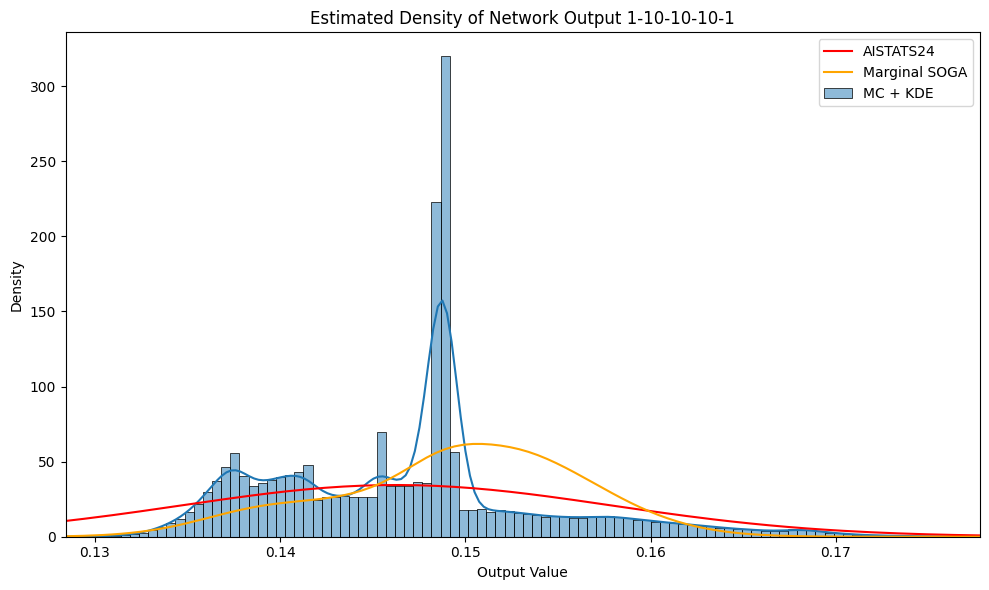

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

pi_plot_bnn = pi_out_bnn.flatten().cpu().detach()
mu_plot_bnn = mu_out_bnn.flatten().cpu().detach()
sg_plot_bnn = sg_out_bnn.flatten().cpu().detach()

pi_plot = pi_out.flatten().cpu().detach() 
mu_plot = mu_out.flatten().cpu().detach()
sg_plot = sg_out.flatten().cpu().detach()


def gmm_density(x, pi, mu, sigma):
    pdf = torch.zeros_like(x)
    for i in range(len(pi)):
        pdf += pi[i] * (1./torch.sqrt(2*np.pi*sigma[i]**2)) * torch.exp(-0.5 * ((x - mu[i]) / sigma[i])**2)
    return pdf

samples_np = out_samples.detach().cpu().numpy().flatten()

plt.figure(figsize=(10, 6))
sns.histplot(samples_np, kde=True, stat='density', bins=100, label='MC + KDE')

x = torch.linspace(samples_np.min(), samples_np.max()+0.2, 500)
output_dist = torch.distributions.MultivariateNormal(mean_mp, var_mp)
pdf = torch.exp(output_dist.log_prob(x.unsqueeze(1)))
plt.plot(x.cpu().numpy(), pdf.cpu().numpy(), label='AISTATS24', color='red')

y_soga = gmm_density(x, pi_plot, mu_plot, sg_plot).cpu().detach()
plt.plot(x.cpu().detach(), y_soga, label='Marginal SOGA', color='orange')

#y_soga_bnn = gmm_density(x, pi_plot_bnn, mu_plot_bnn, sg_plot_bnn).cpu().detach()
#plt.plot(x.cpu().detach(), y_soga_bnn, label='Marginal SOGA-BNN', color='green')

plt.xlabel('Output Value')
plt.xlim(out_samples.min(), out_samples.max().item())
plt.ylabel('Density')
plt.title('Estimated Density of Network Output 1-10-10-10-1')
plt.tight_layout()
plt.legend()
plt.show()

In [22]:
print("MC time:", time_mc)
print("Moment Propagation time:", time_mp)
print("SOGA time:", time_soga)

MC time: [0.005145549774169922]
Moment Propagation time: [0.0009305477142333984]
SOGA time: 0.0442659854888916


In [23]:
print("MC mean:", torch.mean(out_samples, dim=0).item())
print("Moment Propagation mean:", mean_mp)
print("SOGA mean:", mean_soga)

MC mean: 0.1469399858420535
Moment Propagation mean: tensor([[0.1463]], dtype=torch.float64)
SOGA mean: tensor(0.1498, dtype=torch.float64, grad_fn=<SumBackward0>)


In [24]:
print("MC var", torch.var(out_samples, dim=0).item())
print("Moment Propagation var:", var_mp.item())
print("SOGA var:", var_soga.item())


MC var 5.516225910152518e-05
Moment Propagation var: 0.0001341934734378965
SOGA var: 0.0035499707132395746
